# Visualisation des tuiles RGB / Labels / DSM

Ce carnet permet de charger une tuile RGB générée par `create_dataset.py`, d'y superposer les polygones des arbres en semi-transparence et d'afficher la tuile DSM correspondante avec une échelle de couleurs personnalisable.

## Mode d'emploi
1. Ajustez les chemins dans la cellule **Chemins des fichiers**.
2. Exécutez la cellule pour visualiser la tuile RGB avec les labels ainsi que la tuile DSM (palette rouge→bleu ou noir→blanc).

> **Pré-requis** : `rasterio`, `geopandas`, `matplotlib`, `numpy` doivent être installés.

In [2]:

from __future__ import annotations

from pathlib import Path

import json

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from matplotlib.colors import Normalize
from rasterio.plot import show as rio_show, plotting_extent
from shapely.geometry import Polygon

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


In [3]:


def load_raster(path: Path):
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(f"Raster introuvable: {path}")
    with rasterio.open(path) as ds:
        data = ds.read()
        transform = ds.transform
        crs = ds.crs
        profile = ds.profile
    return data, transform, crs, profile


def load_labels(label_path: Path, target_crs) -> gpd.GeoDataFrame:
    gdf = gpd.read_file(label_path)

    if gdf.crs is None:
        minx, miny, maxx, maxy = gdf.total_bounds
        looks_like_latlon = (
            -180 <= minx <= 180 and -180 <= maxx <= 180 and -90 <= miny <= 90 and -90 <= maxy <= 90
        )
        if looks_like_latlon:
            gdf = gdf.set_crs('EPSG:4326')
        elif target_crs is not None:
            print('[INFO] CRS manquant dans les labels — on suppose celui du raster.')
            gdf = gdf.set_crs(target_crs)
        else:
            raise ValueError('CRS manquant dans les labels et aucun CRS cible fourni.')

    if target_crs is not None and gdf.crs != target_crs:
        print(f"[INFO] Reproject {gdf.crs} -> {target_crs}")
        gdf = gdf.to_crs(target_crs)
        print(f"[INFO] CRS après reprojection: {gdf.crs}")

    gdf = gdf[~gdf.geometry.is_empty]
    return gdf


def relative_tile_name(rgb_tile: Path, dataset_root: Path) -> str:
    rgb_tile = Path(rgb_tile)
    dataset_root = Path(dataset_root)
    try:
        rel = rgb_tile.relative_to(dataset_root)
    except ValueError:
        rel = Path(rgb_tile.name)
    return rel.as_posix()


def load_coco_tile_annotations(
    coco_path: Path,
    rgb_tile: Path,
    dataset_root: Path,
    raster_transform,
    target_crs,
) -> gpd.GeoDataFrame:
    coco_path = Path(coco_path)
    if not coco_path.is_file():
        raise FileNotFoundError(f"Fichier COCO introuvable: {coco_path}")

    rel_name = relative_tile_name(rgb_tile, dataset_root)
    with coco_path.open('r', encoding='utf-8') as src:
        coco = json.load(src)

    images = {img['file_name']: img for img in coco.get('images', [])}
    image = images.get(rel_name)
    if image is None:
        raise ValueError(f"Aucune entrée COCO pour '{rel_name}' dans {coco_path}")

    image_id = image['id']
    categories = {cat['id']: cat.get('name', str(cat['id'])) for cat in coco.get('categories', [])}

    rows = []
    geoms = []
    for ann in coco.get('annotations', []):
        if ann.get('image_id') != image_id:
            continue
        segs = ann.get('segmentation') or []
        for seg in segs:
            coords = np.asarray(seg, dtype=np.float64)
            if coords.size < 6:
                continue
            coords = coords.reshape(-1, 2)
            xs, ys = coords[:, 0], coords[:, 1]
            xs_world, ys_world = raster_transform * (xs, ys)
            poly = Polygon(zip(xs_world, ys_world))
            if poly.is_empty or not poly.is_valid:
                continue
            rows.append({
                'category_id': ann.get('category_id'),
                'category_name': categories.get(ann.get('category_id'), str(ann.get('category_id'))),
                'area_px': float(ann.get('area', 0.0)),
                'bbox_px': ann.get('bbox'),
            })
            geoms.append(poly)

    if not rows:
        return gpd.GeoDataFrame(
            {'category_id': [], 'category_name': [], 'area_px': [], 'bbox_px': []},
            geometry=[],
            crs=target_crs,
        )
    return gpd.GeoDataFrame(rows, geometry=geoms, crs=target_crs)


def rgb_to_plot_array(rgb_data: np.ndarray) -> np.ndarray:
    if rgb_data.shape[0] < 3:
        raise ValueError('La tuile RGB doit comporter au moins 3 bandes')
    arr = np.moveaxis(rgb_data[:3], 0, -1).astype(np.float32)
    arr_min, arr_max = arr.min(), arr.max()
    if arr_max > 1 or arr_min < 0:
        arr = (arr - arr_min) / (arr_max - arr_min + 1e-9)
    return np.clip(arr, 0.0, 1.0)


def plot_tile(
    rgb_path: Path,
    dsm_path: Path,
    *,
    label_path: Path | None = None,
    cmap_name: str = 'RdBu_r',
    alpha: float = 0.3,
    label_gdf_override: gpd.GeoDataFrame | None = None,
    tile_extent: tuple[float, float, float, float] | None = None,
):
    rgb_data, transform, crs, _ = load_raster(rgb_path)
    if label_gdf_override is not None:
        label_gdf = label_gdf_override
        if label_gdf.crs is None and crs is not None:
            label_gdf = label_gdf.set_crs(crs)
        elif crs is not None and label_gdf.crs != crs:
            label_gdf = label_gdf.to_crs(crs)
    elif label_path is not None:
        label_gdf = load_labels(label_path, crs)
    else:
        label_gdf = gpd.GeoDataFrame({'geometry': []}, geometry='geometry', crs=crs)

    dsm_data, dsm_transform, _, _ = load_raster(dsm_path)

    rgb_img = rgb_to_plot_array(rgb_data)
    extent = tile_extent if tile_extent is not None else plotting_extent(rgb_data[0], transform)
    dsm_band = dsm_data[0]
    mask = np.isfinite(dsm_band)
    if mask.any():
        vmin = float(np.min(dsm_band[mask]))
        vmax = float(np.max(dsm_band[mask]))
    else:
        vmin, vmax = 0.0, 1.0

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    ax_rgb, ax_dsm, ax_lbl = axes

    ax_rgb.set_title('RGB + Labels')
    ax_rgb.imshow(rgb_img, extent=extent, origin='upper', zorder=0)
    if not label_gdf.empty:
        label_gdf.plot(ax=ax_rgb, facecolor=(0.0, 1.0, 0.0, alpha), edgecolor='lime', linewidth=1.0, zorder=1)
    ax_rgb.set_xlim(extent[0], extent[1])
    ax_rgb.set_ylim(extent[2], extent[3])
    ax_rgb.set_aspect('equal')
    ax_rgb.set_axis_off()

    cmap = plt.get_cmap(cmap_name)
    ax_dsm.set_title(f'DSM ({cmap_name})')
    rio_show(dsm_band, transform=dsm_transform, ax=ax_dsm, cmap=cmap, vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap), ax=ax_dsm, fraction=0.046, pad=0.04)
    cbar.set_label('Altitude (m)')
    ax_dsm.set_axis_off()

    ax_lbl.set_title('Labels seuls')
    ax_lbl.set_xlim(extent[0], extent[1])
    ax_lbl.set_ylim(extent[2], extent[3])
    ax_lbl.set_aspect('equal')
    ax_lbl.set_axis_off()
    if not label_gdf.empty:
        label_gdf.boundary.plot(ax=ax_lbl, edgecolor='green', linewidth=1.2, zorder=1)
        label_gdf.plot(ax=ax_lbl, facecolor=(0.0, 1.0, 0.0, 0.6), edgecolor='none', zorder=1)
    else:
        ax_lbl.text(0.5, 0.5, 'Aucun label', ha='center', va='center', transform=ax_lbl.transAxes)

    plt.tight_layout()
    plt.show()


In [17]:

# === Paramètres principaux ===
DATASET_ROOT = Path('Output')
SPLIT = 'val'  # 'train', 'val' ou 'test'
TILE_ID = '20230608_cbbernard4_p1_r016896_c020992'

RGB_TILE = DATASET_ROOT / SPLIT / 'RGB' / f'{TILE_ID}.tif'
DSM_TILE = DATASET_ROOT / SPLIT / 'DSM' / f'{TILE_ID}.tif'
COCO_JSON = Path('coco') / f'{SPLIT}.json'

DSM_CMAP = 'RdBu_r'   # ou 'gray'
LABEL_ALPHA = 0.30


In [18]:
rgb_data, transform, crs, _ = load_raster(RGB_TILE)
tile_extent = plotting_extent(rgb_data[0], transform)

label_gdf = load_coco_tile_annotations(
    COCO_JSON,
    RGB_TILE,
    DATASET_ROOT,
    transform,
    crs,
)

print('CRS raster:', crs)
print('CRS labels (COCO -> raster):', label_gdf.crs)
print(f"Fichier COCO: {COCO_JSON}")
print(f"Image relative: {relative_tile_name(RGB_TILE, DATASET_ROOT)}")
print(f"Nombre d'annotations: {len(label_gdf)}")
print(f"Bounds estimés: xmin={tile_extent[0]:.3f}, xmax={tile_extent[1]:.3f}, ymin={tile_extent[2]:.3f}, ymax={tile_extent[3]:.3f}")


CRS raster: EPSG:32619
CRS labels (COCO -> raster): PROJCS["WGS 84 / UTM zone 19N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-69],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32619"]]
Fichier COCO: coco/val.json
Image relative: val/RGB/20230608_cbbernard4_p1_r016896_c020992.tif
Nombre d'annotations: 5
Bounds estimés: xmin=293885.105, xmax=293890.395, ymin=5370112.282, ymax=5370117.572


In [19]:

if label_gdf.empty:
    print('Aucun label présent sur cette tuile.')
else:
    height, width = rgb_data.shape[1], rgb_data.shape[2]
    pixel_area = abs(transform.a * transform.e - transform.b * transform.d)
    tile_area = pixel_area * height * width

    if 'area_in_tile' in label_gdf.columns:
        total_label_area = float(label_gdf['area_in_tile'].sum())
    else:
        base_crs = label_gdf.crs
        if getattr(base_crs, 'is_projected', False):
            geom_for_area = label_gdf.geometry
        else:
            estimator = getattr(label_gdf, 'estimate_utm_crs', None)
            utm_crs = estimator() if estimator is not None else None
            if utm_crs is None:
                raise ValueError("Impossible d'estimer un CRS métrique pour calculer les aires.")
            geom_for_area = label_gdf.to_crs(utm_crs).geometry
        total_label_area = float(geom_for_area.area.sum())

    coverage_pct = (total_label_area / tile_area * 100) if tile_area > 0 else 0.0
    coverage_pct = float(np.clip(coverage_pct, 0.0, 100.0))

    print(f"Labels présents : Oui ({len(label_gdf)} polygones)")
    print(f"Surface totale des labels ≈ {total_label_area:.2f} m2")
    print(f"Surface de la tuile ≈ {tile_area:.2f} m2")
    print(f"GSD moyen ≈ {pixel_area**0.5:.3f} m/pixel")
    print(f"Surface couverte ≈ {coverage_pct:.2f}% de la tuile")


Labels présents : Oui (5 polygones)
Surface totale des labels ≈ 8.21 m2
Surface de la tuile ≈ 27.99 m2
GSD moyen ≈ 0.005 m/pixel
Surface couverte ≈ 29.32% de la tuile


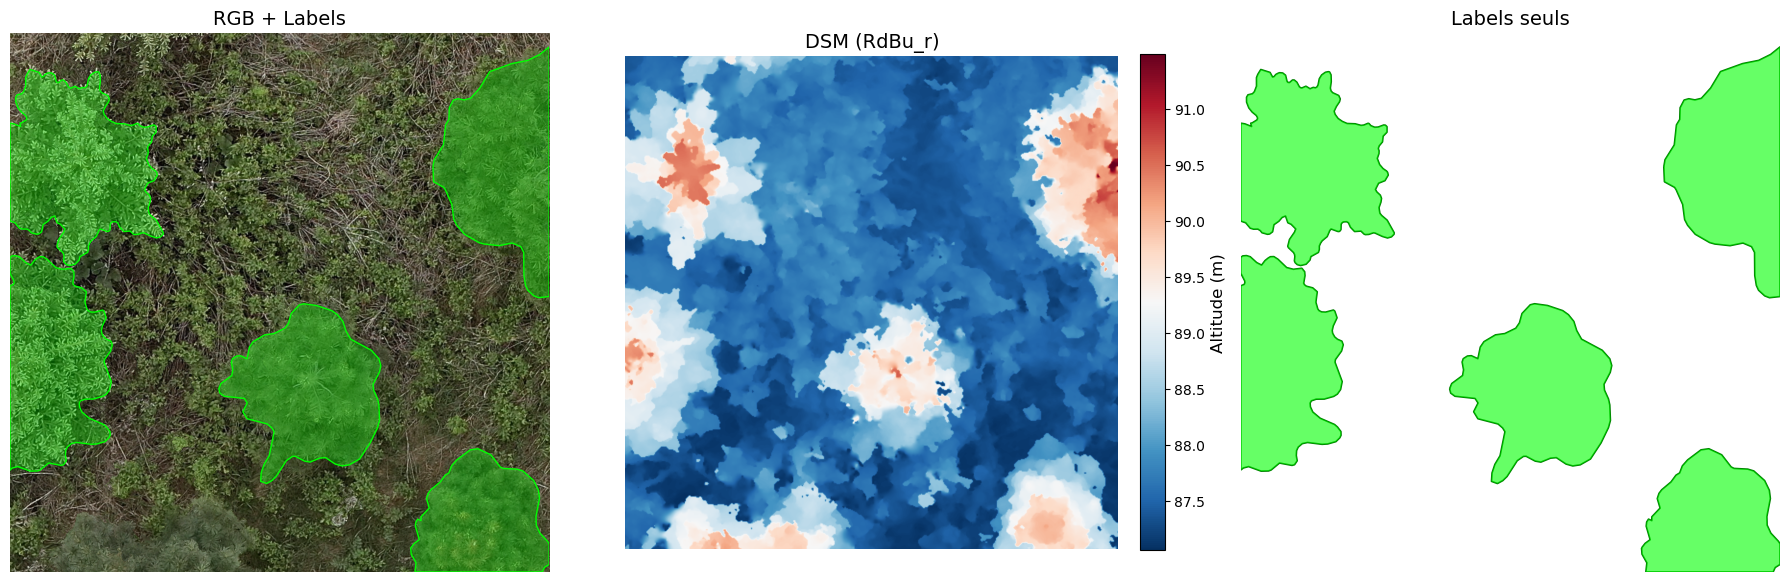

In [20]:

plot_tile(
    RGB_TILE,
    DSM_TILE,
    cmap_name=DSM_CMAP,
    alpha=LABEL_ALPHA,
    label_gdf_override=label_gdf,
    tile_extent=tile_extent,
)


In [21]:

print(f"{len(label_gdf)} polygones chargés depuis COCO")
display(label_gdf.head(2))


5 polygones chargés depuis COCO


,category_id,category_name,area_px,bbox_px,geometry
0,5,pist,45606.431320,"[761.0623008906841, 789.9641954898834, 262.937...","POLYGON ((293890.395 5370112.356, 293890.348 5..."
1,5,pist,63181.013278,"[396.5608763024211, 514.5152570009232, 307.860...","POLYGON ((293887.49 5370114.542, 293887.603 53..."
